In [1]:
# Tutorial 4: Data Augmentation

### Cell 1: Import Necessary Libraries

In [2]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt
import os

# For the neural network part of the tutorial
import torch.nn as nn

### Cell 2: Define Folders and Paths

In [4]:
# Define your base directory and image path
base_path = r"C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials"
img_path = os.path.join(base_path, "Image.jpg")

# Define the folder where augmented images will be saved
save_folder = os.path.join(base_path, "PyTorch_Augmented_Images")

# Create the folder if it doesn't exist
os.makedirs(save_folder, exist_ok=True)

### Cell 3: Initialize Augmentation Parameters

In [6]:
# Define the transformation pipeline to introduce variability 
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=40),              # rotation_range=40 
    transforms.RandomAffine(degrees=0, shear=15),       # shear_range=0.2 (approx 15 deg) 
    transforms.RandomResizedCrop(size=(224, 224),scale=(0.8, 1.2)),     # zoom_range=0.2 
    transforms.RandomHorizontalFlip(p=0.5),             # horizontal_flip=True 
    transforms.ColorJitter(brightness=(0.5, 1.5)),      # brightness_range=(0.5, 1.5) 
    transforms.ToTensor()                               # Convert to Tensor for saving
])

### Cell 4: Define the Neural Network Architecture

In [7]:
# Build the neural network model 
model = nn.Sequential(
    nn.Flatten(),                          # Flatten 28x28 images to 784 features 
    nn.Linear(28 * 28, 128),               # Hidden Layer with 128 neurons 
    nn.ReLU(),                             # ReLU activation 
    nn.Linear(128, 64),                    # Hidden Layer with 64 neurons 
    nn.ReLU(),                             # ReLU activation 
    nn.Linear(64, 10),                     # Output layer with 10 neurons
    nn.LogSoftmax(dim=1)                   # Softmax activation for 10 digits 
)

print(model) # Display architecture 

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
  (6): LogSoftmax(dim=1)
)


### Cell 5: Generate and Save Augmented Images

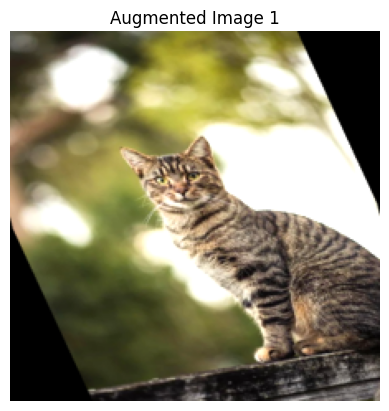

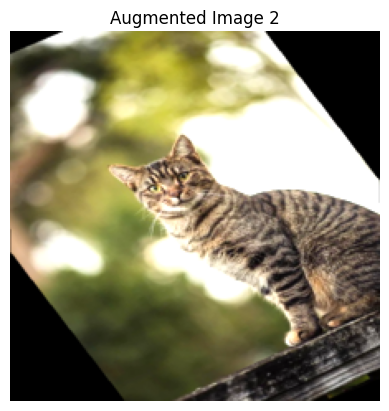

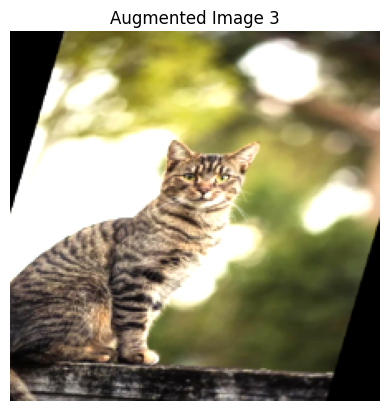

Success! 40 images saved in: C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\PyTorch_Augmented_Images


In [8]:
# Step 4: Load the Image
# PyTorch works best with PIL format for transforms
img = Image.open(img_path).convert("RGB")

# Step 6: Generate and Save 40 Augmented Images 
for i in range(1, 41):
    # Apply random transformations
    augmented_tensor = augmentation_transforms(img)
    
    # Define save path
    save_path = os.path.join(save_folder, f"aug_image_{i}.jpg") 
    
    # Save image to the folder
    save_image(augmented_tensor, save_path) 
    
    # Display the first few for visualization in Jupyter 
    if i <= 3:
        plt.figure()
        plt.imshow(augmented_tensor.permute(1, 2, 0)) # Reorder channels for plotting [cite: 60]
        plt.title(f"Augmented Image {i}")
        plt.axis('off') 
        plt.show()

# Step 7: Confirm Location 
print(f"Success! 40 images saved in: {os.path.abspath(save_folder)}") 